# Analysis of Global Properties

In [1]:
import json
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import polars as pl
from r_utils import fit_lmer_full
from plot_utils import _configure_fonts, plot_emmeans_grouped_bar, SETTING_COLOR, SETTING_MAP, GRAPH_MAP, SETTING_MARKER
import matplotlib.pyplot as plt

_configure_fonts()
# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))


Error importing in API mode: ImportError("dlopen(/Users/gs/Documents/GitHub/llm-debate-sim/.venv/lib/python3.12/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <85D47EFD-9B5F-368A-BC00-EBCFE4080F31> /Users/gs/Documents/GitHub/llm-debate-sim/.venv/lib/python3.12/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [2]:
ROLE_TO_IDX = {
    "Strategic Planner": 0,
    "Language Mediator": 1,
    "Online Friend": 2,
    "Software Engineer": 3,
    "Academic Scholar": 4,
    "Chemist": 5,
    "Human Participant": 6,
    "LLM": 7,
    "Cybersecurity Analyst": 8,
    "Mathematician": 9,
    "Storyteller": 10,
    "Clinical Physician": 11,
    "Biomedical Researcher": 12,
    "Financial Analyst": 13,
    "Lexicographer": 14,
    "Assistant": 15,
}

MATCHES = [
    ("llama-doc", "Clinical Physician"),
    ("llama-base", "LLM"),
    ("llama-base", "Human Participant"),
    ("llama-assistant", "Assistant"),
    ("llama-biomed", "Biomedical Researcher"),
    ("llama-chemist", "Chemist"),
    ("llama-coder", "Software Engineer"),
    ("llama-cyber", "Cybersecurity Analyst"),
    ("llama-finance", "Financial Analyst"),
    ("llama-hermes", "Strategic Planner"),
    ("llama-openmath", "Mathematician"),
    ("llama-lexicographer", "Lexicographer"),
    ("llama-linguist", "Language Mediator"),
    ("llama-roleplay", "Storyteller"),
    ("llama-scholar", "Academic Scholar"),
    ("llama-user", "Online Friend"),
]

def save_model_results(results_dict: dict, name: str, save_path: Path):
    '''
    Save results to CSV or JSON files in a structured directory (from fit_lmer_full)
    '''
    save_path = save_path / f"{name}"
    save_path.mkdir(parents=True, exist_ok=True)
    for key, df in results_dict.items():
        if isinstance(df, pd.DataFrame):
            df.to_csv(save_path / f"{key}.csv", index=True)
        else:
            with open(save_path / f"{key}.json", "w") as f:
                json.dump(df, f, indent=4)


In [3]:
data_path = Path.cwd().parent / "data" / "outputs" / "aggregated"
result_path = Path.cwd().parent / "data" / "analysis" 
result_path.mkdir(parents=True, exist_ok=True)

agg_path = result_path / "aggregated" / "runs"
cts_path = result_path / "contrasts" / "runs"
con_path = result_path / "continuous" / "runs"

agg_path.mkdir(parents=True, exist_ok=True)
cts_path.mkdir(parents=True, exist_ok=True)
con_path.mkdir(parents=True, exist_ok=True)

lfs = pl.read_parquet(data_path / "run_level_data.parquet")

dft = lfs.to_pandas()
lfs.sample(10, seed=0)

T,statement_id,setting,seed,graph_seed,graph_id,graph_type,modal_consensus_T,modal_consensus_0,modal_consensus_mean,modal_consensus_change,polarization_T,polarization_0,polarization_mean,polarization_change,polarization_change_1,entropy_T,entropy_0,entropy_change,n_distinct_labels_T,majority_label_T,majority_share_T,ground_truth,net_num_nodes,net_num_edges,net_radius,net_diameter,net_degree_mean,net_degree_median,net_degree_std,net_triangles,net_wedges,net_avg_path_length,net_num_components,net_avg_clustering,net_global_clustering_coefficient,net_density,accuracy_0,accuracy_T,diff_accuracy,run_id
i64,cat,cat,i64,cat,str,cat,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,i64,i64,i64,i64,f64,f64,f64,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,cat
10,"""false_7""","""random_roles""",597409993,"""851350617""","""watts-strogatz-597409993""","""watts-strogatz""",1.0,1.0,1.0,0.0,0.002976,0.002539,0.002534,0.000437,0.000325,-0.0,-0.0,0.0,1,1,1.0,0.0,48,192,3,5,8.0,8.0,0.816497,244,1360,2.620567,1,0.549024,0.538235,0.170213,0.985168,0.993449,0.00828,"""random_roles:watts-strogatz-59…"
10,"""false_8""","""random_roles""",900911955,"""43019216""","""erdos-renyi-900911955""","""erdos-renyi""",0.958333,0.875,0.892045,0.083333,0.091801,0.170422,0.193514,-0.078621,-0.060398,0.173205,0.37677,-0.203565,2,1,0.958333,0.0,48,325,2,3,13.541667,13.0,3.936783,477,4448,1.734043,1,0.337969,0.321718,0.288121,0.610258,0.94249,0.332232,"""random_roles:erdos-renyi-90091…"
10,"""true_0""","""random_roles""",1170252924,"""365860106""","""watts-strogatz-1170252924""","""watts-strogatz""",0.791667,0.5625,0.736742,0.229167,0.325044,0.119614,0.320496,0.20543,-0.086582,0.51174,0.685314,-0.173574,2,1,0.791667,1.0,48,192,3,5,8.0,8.0,0.5,258,1350,2.615248,1,0.577612,0.573333,0.170213,0.470406,0.241779,-0.228627,"""random_roles:watts-strogatz-11…"
10,"""false_0""","""base_llms""",597409993,"""3798279163""","""erdos-renyi-597409993""","""erdos-renyi""",1.0,1.0,1.0,0.0,0.002932,0.0,0.002666,0.002932,0.0,-0.0,-0.0,0.0,1,1,1.0,0.0,48,327,2,3,13.625,14.0,3.289028,415,4388,1.725177,1,0.287361,0.283728,0.289894,0.916504,0.971863,0.055359,"""base_llms:erdos-renyi-59740999…"
10,"""true_9""","""random_roles""",1265438423,"""2701326989""","""erdos-renyi-1265438423""","""erdos-renyi""",1.0,1.0,1.0,0.0,0.007083,0.156288,0.019737,-0.149205,-0.001752,-0.0,-0.0,0.0,1,0,1.0,1.0,48,371,2,3,15.458333,16.0,3.973655,665,5743,1.68617,1,0.346894,0.347379,0.328901,0.755341,0.98877,0.233429,"""random_roles:erdos-renyi-12654…"
10,"""false_4""","""base_llms""",473392625,"""3830640276""","""watts-strogatz-473392625""","""watts-strogatz""",1.0,1.0,1.0,0.0,0.000428,0.0,0.000389,0.000428,0.0,-0.0,-0.0,0.0,1,1,1.0,0.0,48,192,3,4,8.0,8.0,0.645497,211,1354,2.35195,1,0.472007,0.467504,0.170213,0.986328,0.993795,0.007467,"""base_llms:watts-strogatz-47339…"
10,"""false_4""","""experts""",1738238662,"""4262934205""","""watts-strogatz-1738238662""","""watts-strogatz""",0.916667,0.8125,0.922348,0.104167,0.222879,0.350225,0.249878,-0.127346,-0.067015,0.286836,0.601924,-0.315088,2,1,0.916667,0.0,48,192,3,4,8.0,8.0,0.978945,186,1367,2.277482,1,0.42336,0.408193,0.170213,0.703794,0.831669,0.127875,"""experts:watts-strogatz-1738238…"
10,"""false_5""","""experts""",814183,"""1769674741""","""watts-strogatz-814183""","""watts-strogatz""",1.0,0.9375,0.994318,0.0625,0.139609,0.271736,0.145846,-0.132128,-0.029858,-0.0,0.233792,-0.233792,1,0,1.0,0.0,48,192,3,4,8.0,8.0,1.307032,193,1385,2.278369,1,0.438337,0.418051,0.170213,0.198701,0.055215,-0.143486,"""experts:watts-strogatz-814183:…"
10,"""false_2""","""random_roles""",1265438423,"""2701326989""","""erdos-renyi-1265438423""","""erdos-renyi""",1.0,1.0,1.0,0.0,0.003413,0.033656,0.00612,-0.030243,-0.00105,-0.0,-0.0,0.0,1,0,1.0,0.0,48,371,2,3,15.458333,16.0,3.973655,665,5743,1.68617,1,0.346894,0.347379,0.328901,0.051164,0.001234,-0.04993,"""random_roles:erdos-renyi-12654…"


In [4]:
dft = lfs.to_pandas()
dft['setting'] = pd.Categorical(
    dft['setting'], 
    categories=["base_llms", "random_roles", "random_experts", "experts"], 
    ordered=False 
)
dft['graph_type'] = pd.Categorical(dft['graph_type'],
                                  categories=sorted(dft['graph_type'].unique()),
                                  ordered=False)
dft['statement_id'] = pd.Categorical(dft['statement_id'],
                                  categories=sorted(dft['statement_id'].unique()),
                                  ordered=False)
dft['graph_seed'] = pd.Categorical(dft['graph_seed'],
                                  categories=sorted(dft['graph_seed'].unique()),
                                  ordered=False)

dft['run_id'] = (
    dft['setting'].astype(str) + ':' +
    dft['graph_id'].astype(str) + ':' +
    dft['statement_id'].astype(str)
)
dft['run_id'] = pd.Categorical(dft['run_id'], categories=sorted(dft['run_id'].unique()))


dft["degree_mean_z"] = (dft["net_degree_mean"] - dft["net_degree_mean"].mean()) / dft["net_degree_mean"].std()
dft["clustering_mean_z"] = (dft["net_avg_clustering"] - dft["net_avg_clustering"].mean()) / dft["net_avg_clustering"].std()
dft["avg_path_length_z"] = (dft["net_avg_path_length"] - dft["net_avg_path_length"].mean()) / dft["net_avg_path_length"].std()

dft.columns

Index(['T', 'statement_id', 'setting', 'seed', 'graph_seed', 'graph_id',
       'graph_type', 'modal_consensus_T', 'modal_consensus_0',
       'modal_consensus_mean', 'modal_consensus_change', 'polarization_T',
       'polarization_0', 'polarization_mean', 'polarization_change',
       'polarization_change_1', 'entropy_T', 'entropy_0', 'entropy_change',
       'n_distinct_labels_T', 'majority_label_T', 'majority_share_T',
       'ground_truth', 'net_num_nodes', 'net_num_edges', 'net_radius',
       'net_diameter', 'net_degree_mean', 'net_degree_median',
       'net_degree_std', 'net_triangles', 'net_wedges', 'net_avg_path_length',
       'net_num_components', 'net_avg_clustering',
       'net_global_clustering_coefficient', 'net_density', 'accuracy_0',
       'accuracy_T', 'diff_accuracy', 'run_id', 'degree_mean_z',
       'clustering_mean_z', 'avg_path_length_z'],
      dtype='str')

## Aggregates

In [5]:
COL_RUN_PRETTY_NAMES = {
    'modal_consensus_T': 'Modal Consensus',
    'modal_consensus_change': 'Modal Consensus Change (T-0)',
    'polarization_T': 'Polarization',
    'polarization_change': 'Polarization Change (T-0)',
    # 'polarization_change_1': 'Polarization Change (T-1)',
    
}

INFO:root:Coefficients extracted successfully.
INFO:root:ANOVA table extracted successfully.
INFO:root:EMMs extracted successfully.
INFO:root:Fit statistics extracted successfully.
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern pruned
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:Zapf dropped
INFO:fontTools.subset:feat dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:morx dropped
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'glyf': 46 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'B', 'C', 'E', 'G', 'I', 'L', 'M', 'R', 'S', 'V', 'W', 'a', 'c', 'd', 'e', 'eacute', 'eight', 'four', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'ohungarumlaut', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'six', 'space', 't', 'two', 'u', 'x', 'y

Finished fitting model for modal_consensus_T with setting * graph_type
Saved figure to: /Users/gs/Documents/GitHub/llm-debate-sim/data/analysis/aggregated/runs/modal_consensus_T_grouped_bar.pdf


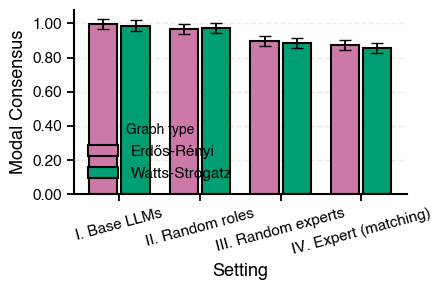

  
INFO:root:Coefficients extracted successfully.
INFO:root:ANOVA table extracted successfully.
INFO:root:EMMs extracted successfully.
INFO:root:Fit statistics extracted successfully.
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern pruned
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:Zapf dropped
INFO:fontTools.subset:feat dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:morx dropped
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'glyf': 45 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'B', 'C', 'E', 'G', 'I', 'L', 'M', 'R', 'S', 'T', 'V', 'W', 'a', 'c', 'd', 'e', 'eacute', 'five', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'ohungarumlaut', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'space', 't', 'two', 'u', 'x', 'y', 'z', 

Finished fitting model for modal_consensus_change with setting * graph_type
Saved figure to: /Users/gs/Documents/GitHub/llm-debate-sim/data/analysis/aggregated/runs/modal_consensus_change_grouped_bar.pdf


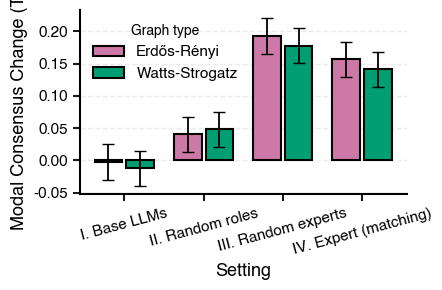

  
INFO:root:Coefficients extracted successfully.
INFO:root:ANOVA table extracted successfully.
INFO:root:EMMs extracted successfully.
INFO:root:Fit statistics extracted successfully.
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern pruned
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:Zapf dropped
INFO:fontTools.subset:feat dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:morx dropped
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'glyf': 43 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'B', 'E', 'G', 'I', 'L', 'M', 'P', 'R', 'S', 'V', 'W', 'a', 'c', 'd', 'e', 'eacute', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'ohungarumlaut', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'space', 't', 'three', 'two', 'x', 'y', 'z', 'zero']
I

Finished fitting model for polarization_T with setting * graph_type
Saved figure to: /Users/gs/Documents/GitHub/llm-debate-sim/data/analysis/aggregated/runs/polarization_T_grouped_bar.pdf


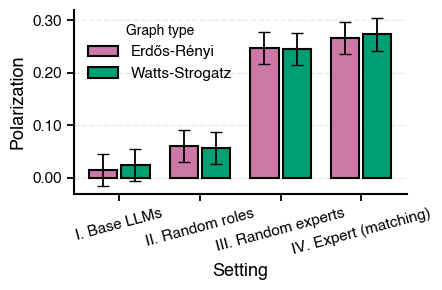

INFO:root:Coefficients extracted successfully.
INFO:root:ANOVA table extracted successfully.
INFO:root:EMMs extracted successfully.
INFO:root:Fit statistics extracted successfully.
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern pruned
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:Zapf dropped
INFO:fontTools.subset:feat dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:morx dropped
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'glyf': 44 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'B', 'C', 'E', 'G', 'I', 'L', 'M', 'P', 'R', 'S', 'T', 'V', 'W', 'a', 'c', 'd', 'e', 'eacute', 'five', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'ohungarumlaut', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'space', 't', 'x', 'y', 'z', 'zero']
IN

Finished fitting model for polarization_change with setting * graph_type
Saved figure to: /Users/gs/Documents/GitHub/llm-debate-sim/data/analysis/aggregated/runs/polarization_change_grouped_bar.pdf


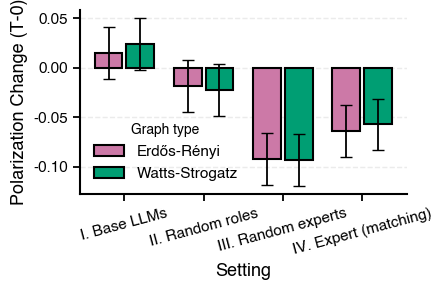

In [6]:
for col in COL_RUN_PRETTY_NAMES.keys():
    var_name = col
    res = fit_lmer_full(
    df=dft,
    specification=f'''
        {var_name} ~ setting * graph_type + 
        (1 | statement_id) + 
        (1 | graph_type:graph_seed) 
    ''',
    emm_formula='~setting * graph_type',
    reml=True,  
    # lmer_df="asymptotic",
)
    save_model_results(res, f"{var_name}_setting_graph_type", agg_path)
    print(f"Finished fitting model for {var_name} with setting * graph_type")
    fig, ax, emm_plot = plot_emmeans_grouped_bar(
        emm_df=res["emm"],
        setting_reference=dft if "dft" in globals() else None,
        y_label=f"{COL_RUN_PRETTY_NAMES.get(var_name, var_name)}",
        title="",
        show=True,
        figsize=(4.5, 3),
        out_fig= agg_path / f"{var_name}_grouped_bar.pdf",
    )

## Contrast

In [7]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from typing import Any
import pandas as pd

def fit_lmer_with_contrasts(
    df: pd.DataFrame,
    outcome: str,
    spec_extra: str = "* graph_type",   # additional fixed-effect terms beyond `setting`
    random_effects: str = "(1 | statement_id) + (1 | graph_id)",  # random effects formula
    reml: bool = True,
) -> dict[str, Any]:
    """
    Fit a mixed-effects model with setting as a fixed effect and compute the
    four planned causal contrasts from the four-setting natural experiment.

    Contrasts (assuming setting levels = base_llms, random_roles, random_experts, experts):
        - role_effect:     random_roles - base_llms             (role effect, model constant)
        - model_effect:     random_experts - random_roles        (model effect, role constant)
        - alignment:     experts - random_experts             (role-model alignment effect)
        - dissociation:  avg(heterogeneous) - avg(homogeneous)

    Returns dict with: model_anova, emm_settings, contrasts, fit_stats.
    """
    specification = f"{outcome} ~ setting {spec_extra} + {random_effects}"
    emm_formula   = f"setting {spec_extra}"
    
    with (ro.default_converter + pandas2ri.converter).context():
        ro.globalenv["df"] = ro.conversion.py2rpy(df)
        ro.globalenv["spec"] = specification
        ro.globalenv["emm_formula"] = emm_formula
        ro.globalenv["use_reml"] = reml
        
        ro.r('''
            library(lmerTest)
            library(emmeans)
            emm_options(pbkrtest.limit = 100000, lmerTest.limit = 100000)

            df$setting <- factor(df$setting,
                                levels = c("base_llms", "random_roles",
                                            "random_experts", "experts"))

            df_model <- lmerTest::lmer(as.formula(spec), data = df, REML = use_reml)

            contr_list <- list(
                role_eff     = c(-1, 1, 0, 0),
                model_eff    = c(0, -1, 1, 0),
                alignment    = c(0, 0, -1, 1),
                dissociation = c(-0.5, -0.5, 0.5, 0.5)
            )

            # --- (1) Marginal contrasts: averaged over graph_type
            emm_marginal <- emmeans(df_model, ~ setting, lmer.df = "satterthwaite")
            contrasts_marginal <- as.data.frame(contrast(emm_marginal, contr_list, adjust = "none"))
            ci_marginal <- as.data.frame(confint(contrast(emm_marginal, contr_list, adjust = "none")))
            contrasts_marginal$lower.CL <- ci_marginal$lower.CL
            contrasts_marginal$upper.CL <- ci_marginal$upper.CL

            # --- (2) Within-graph (simple effects)
            emm_within <- emmeans(df_model, ~ setting | graph_type, lmer.df = "satterthwaite")
            within_obj <- contrast(emm_within, contr_list, adjust = "none")
            contrasts_within <- as.data.frame(within_obj)
            ci_within <- as.data.frame(confint(within_obj))
            contrasts_within$lower.CL <- ci_within$lower.CL
            contrasts_within$upper.CL <- ci_within$upper.CL

            # --- (3) Interaction contrasts: (contrast | WS) - (contrast | ER)
            interaction_obj <- pairs(within_obj, by = "contrast", adjust = "none")
            contrasts_interaction <- as.data.frame(interaction_obj)
            ci_interaction <- as.data.frame(confint(interaction_obj))
            contrasts_interaction$lower.CL <- ci_interaction$lower.CL
            contrasts_interaction$upper.CL <- ci_interaction$upper.CL

            # EMMs for plotting (8-cell grid)
            emm_full <- as.data.frame(
                emmeans(df_model, ~ setting * graph_type, lmer.df = "satterthwaite")
            )

            anova_out <- as.data.frame(anova(df_model))
            anova_out$Term <- rownames(anova_out)

            fit_stats <- data.frame(
                AIC = AIC(df_model),
                BIC = BIC(df_model),
                logLik = as.numeric(logLik(df_model))
            )
        ''')
        
        return {
            "anova":                  ro.conversion.rpy2py(ro.r("anova_out")),
            "emm":                    ro.conversion.rpy2py(ro.r("emm_full")),
            "contrasts_marginal":     ro.conversion.rpy2py(ro.r("contrasts_marginal")),
            "contrasts_within":       ro.conversion.rpy2py(ro.r("contrasts_within")),
            "contrasts_interaction":  ro.conversion.rpy2py(ro.r("contrasts_interaction")),
            "fit_stats":              ro.conversion.rpy2py(ro.r("fit_stats")),
            
        }

In [13]:
from torch import rand


_contrast_path = result_path / "contrasts"
_contrast_path.mkdir(parents=True, exist_ok=True)

col_list = [
    "modal_consensus_T",
    "polarization_T",
    # "entropy_T",
    # "entropy_change",
    # 'polarization_change',
    'modal_consensus_change',
    # 'accuracy_T',
]
def build_contrast_summary(col_list, results_dict, dft):
    rows = []
    for col in col_list:
        out = results_dict[col]
        outcome_sd = dft[col].std()

        for ctype in ("marginal", "within", "interaction"):
            tbl = out.get(f"contrasts_{ctype}")
            if tbl is None:
                continue
            for _, row in tbl.iterrows():
                rows.append({
                    "outcome":       col,
                    "contrast_type": ctype,
                    "graph_type":    row.get("graph_type", pd.NA),
                    "contrast":      row["contrast"],
                    "estimate":      row["estimate"],
                    "std_estimate":  row["estimate"] / outcome_sd,
                    "SE":            row["SE"],
                    "std_SE":        row["SE"] / outcome_sd,
                    "t":             row["t.ratio"],
                    "df":            row.get("df", pd.NA),
                    "p":             row["p.value"],
                    "lower":         row["lower.CL"],
                    "upper":         row["upper.CL"],
                    "std_lower":     row["lower.CL"] / outcome_sd,
                    "std_upper":     row["upper.CL"] / outcome_sd,
                    "sig":           row["p.value"] < 0.05,
                })
    return pd.DataFrame(rows)

# Run the contrast pipeline first, collecting results into a dict
results_dict = {}
for col in col_list:
    results_dict[col] = fit_lmer_with_contrasts(dft, outcome=col, spec_extra='* graph_type',random_effects="(1 | statement_id) + (1 | graph_id)", reml=True)

summary = build_contrast_summary(col_list, results_dict, dft)
summary.to_csv(cts_path / "contrast_summary.csv", index=False)

## How important are graph features?
#### ANOVA

In [11]:
# Structural
out = fit_lmer_with_contrasts(
    dft,
    outcome='entropy_T',
    spec_extra='* (degree_mean_z + avg_path_length_z)',
)

out['anova'].round(3)

  
  No variable named graph_type in the reference grid
  


RRuntimeError: Error in emmeans(df_model, ~setting | graph_type, lmer.df = "satterthwaite") : 
  No variable named graph_type in the reference grid


In [ ]:
# Structural
out = fit_lmer_with_contrasts(
    dft,
    outcome='modal_consensus_T',
    spec_extra='* (degree_mean_z + avg_path_length_z)',
)

out['anova'].round(3)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F),Term
setting,3.600,1.200,3,1249.0,215.643,0.000,setting
degree_mean_z,0.010,0.010,1,1249.0,1.765,0.184,degree_mean_z
avg_path_length_z,0.022,0.022,1,1249.0,3.956,0.047,avg_path_length_z
setting:degree_mean_z,0.021,0.007,3,1249.0,1.284,0.278,setting:degree_mean_z
setting:avg_path_length_z,0.031,0.010,3,1249.0,1.862,0.134,setting:avg_path_length_z


In [ ]:
# Structural
out = fit_lmer_with_contrasts(
    dft,
    outcome='accuracy_T',
    spec_extra='* (degree_mean_z + avg_path_length_z)',
)

out['anova'].round(3)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F),Term
setting,1.344,0.448,3,1249.0,18.610,0.000,setting
degree_mean_z,0.000,0.000,1,1249.0,0.002,0.966,degree_mean_z
avg_path_length_z,0.000,0.000,1,1249.0,0.001,0.971,avg_path_length_z
setting:degree_mean_z,0.021,0.007,3,1249.0,0.296,0.829,setting:degree_mean_z
setting:avg_path_length_z,0.001,0.000,3,1249.0,0.014,0.998,setting:avg_path_length_z


### Fit

In [ ]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter

def get_degree_slopes(df, outcome: str, var: str = "degree_z"):
    """
    Fit setting * graph_type * degree_z model and extract per-cell degree slopes.
    Returns a dataframe with 8 rows (4 settings × 2 graph types) and the
    estimated slope of `var` within each cell.
    """
    spec = (f"{outcome} ~ setting * graph_type * {var} + "
            f"(1 | statement_id) + (1 | graph_id)")
    
    with localconverter(default_converter + pandas2ri.converter):
        ro.globalenv['df_r'] = df
        ro.globalenv['spec'] = spec
        ro.globalenv['var_name'] = var
        
        ro.r('''
            library(lmerTest)
            library(emmeans)
            emm_options(pbkrtest.limit = 100000, lmerTest.limit = 100000)
            
            df_model <- lmer(as.formula(spec), data = df_r, REML = TRUE)
            
            slopes <- as.data.frame(
                emtrends(df_model, ~ setting * graph_type, var = var_name, lmer.df = "satterthwaite")
            )
        ''')
        slopes = ro.r['slopes']
    
    return slopes

In [ ]:

rows = []
for col in ['entropy_T', 'modal_consensus_T', 'polarization_T', 'entropy_change', 'polarization_change', 'modal_consensus_change']:
    var_name = "avg_path_length_z"
    slopes = get_degree_slopes(dft, outcome=col, var=var_name)
    outcome_sd = dft[col].std()  # for standardization
    for _, row in slopes.iterrows():
        rows.append({
            'outcome': col,
            'effect_col': var_name,
            'setting': row['setting'],
            'graph_type': row['graph_type'],
            'trend': row[f'{var_name}.trend'],
            'se': row['SE'],
            'df': row['df'],
            'lower': row['lower.CL'],
            'upper': row['upper.CL'],
        })
    print(f"Finished extracting slopes for {col}")
degree_trends = pd.DataFrame(rows)
degree_trends.to_csv(con_path / "avg_path_length_trends.csv", index=False)

Finished extracting slopes for entropy_T
Finished extracting slopes for modal_consensus_T
Finished extracting slopes for polarization_T
Finished extracting slopes for entropy_change


Finished extracting slopes for polarization_change
Finished extracting slopes for modal_consensus_change


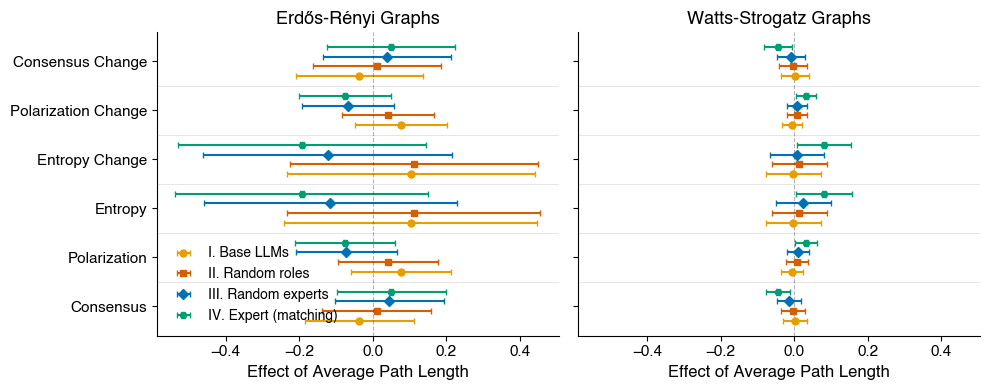

In [ ]:
def plot_slope_forest(degree_trends, outcomes_order=None, figsize=(10, 4)):
    df = degree_trends.copy()
    
    if outcomes_order is None:
        outcomes_order = df['outcome'].unique().tolist()
    
    setting_order = ['base_llms', 'random_roles', 'random_experts', 'experts']
    colors = SETTING_COLOR

    
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True, sharex=True)
    
    for ax, graph_type in zip(axes, ['erdos-renyi', 'watts-strogatz']):
        sub = df[df['graph_type'] == graph_type]
        labeled_settings = set()
        
        for s_idx, setting in enumerate(setting_order):
            sub_s = sub[sub['setting'] == setting]
            offset = (s_idx - 1.5) * 0.20  # spread out within each outcome row
            
            for _, row in sub_s.iterrows():
                y = outcomes_order.index(row['outcome']) + offset
                label = SETTING_MAP[setting] if setting not in labeled_settings else None
                ax.errorbar(
                    row['trend'], y,
                    xerr=[[row['trend'] - row['lower']], [row['upper'] - row['trend']]],
                    fmt=SETTING_MARKER[setting],
                    color=colors[setting], capsize=2, markersize=5,
                    label=label,
                )
                labeled_settings.add(setting)
        
        ax.axvline(0, color='k', linestyle='--', alpha=0.3, linewidth=0.8)
        for y_sep in np.arange(len(outcomes_order) - 1) + 0.5:
            ax.axhline(y_sep, color='0.85', linewidth=0.7, alpha=0.7, zorder=0)
        ax.set_ylim(-0.6, len(outcomes_order) - 0.4)
        ax.set_title(f"{GRAPH_MAP[graph_type]} Graphs", fontsize=13)
        ax.set_xlabel('Effect of Average Path Length', fontsize=12)
        ax.spines[['top', 'right']].set_visible(False)
    
    axes[0].set_yticks(range(len(outcomes_order)))
    axes[0].set_yticklabels([COL_RUN_PRETTY_NAMES[outcome] for outcome in outcomes_order])
    axes[0].legend(loc='lower left', fontsize=10, frameon=False)
    plt.tight_layout()
    return fig

cols_to_choose = [
    "modal_consensus_T",
    "polarization_T",
    "entropy_T",
    "entropy_change",
    "polarization_change",
    "modal_consensus_change"
]

trends_filtered = degree_trends[degree_trends['outcome'].isin(
     cols_to_choose
    )]
fig = plot_slope_forest(trends_filtered, outcomes_order=cols_to_choose)
fig.savefig(con_path / "avg_path_length_slope_forest.pdf", dpi=300, bbox_inches='tight')